### Create Snow-17 Forcing files from HRRR-AK Data: PPSA2

Notebook contents 
* Create Snow-17 forcing files, look at example structure, esp careful of precip units 

created by Cassie Lumbrazo\
last updated: Feb 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

In [2]:
import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

In [3]:
from zoneinfo import ZoneInfo
from pathlib import Path

In [4]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/ppsa2'

## Load the HRRR Dataset, 
that we created in `2_clean_hrrrak_netcdf.ipynb`, a test for WY2024 for now

In [5]:
input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_ppsa2.nc"
ds = xr.open_dataset(input_file)
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 8760)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2024-10-01T05:00:00 ... 2025-10-...
    valid_time    (time) datetime64[ns] 70kB ...
    step          (time) timedelta64[ns] 70kB ...
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time) float64 70kB ...
    pressure      (time) float64 70kB ...
    orog          (time) float64 70kB ...
    temp_surface  (time) float64 70kB ...
    swe           (time) float64 70kB ...
    snowdepth     (time) float64 70kB ...
    ...            ...
    swrad         (time) float64 70kB ...
    lwrad         (time) float64 70kB ...
    suswrf        (time) float64 70kB ...
    sulwrf        (time) float64 70kB ...
    wind          (time) float64 70kB ...
    wind_dir      (time) float64 70kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       ppsa2
    original_lat:    58.262
    original_lon:    -134.517
    utm_x:           528340.7656649345
    utm_y:           6457981.62778889

## Set Up Precipitation Variables
See comments for this in script `2_compare_precipitation.ipynb`

### Precipitation Variables from HRRR-AK
`ds.precip_total` accumulated precipitation since forecast start\
units: kg/m²\
range: 0–20

`ds.precip_rate` is the precipiation rate\
units: kg/m²/s\
range: 0–0.0035

Then, we can create a variable, which would be used in the model, which is the `precip_rate` accumulated over the model timestep (i.e., 1 hr)\
`ds.precip_accum_1hr`

In [6]:
ds['precip_accum_1hr'] = ds['precip_rate'] * 3600 # convert from mm/s to mm/hr
ds["precip_total_accum"] = ds.precip_accum_1hr.cumsum(dim="time") # total in mm accumulated precip over the time period

In [7]:
# ds.temp.plot() # 2-m surface temperature in K, need in K
# ds.rh.plot() # 2-m relative humidity in %, need in fraction (0-1)
# ds.u10.plot() # 10-m u wind component in m/s, need in m/s
# ds.v10.plot() # 10-m v wind component in m/s, need in m/s
# ds.swrad.plot() # surface downward shortwave radiation in W/m2, need in W/m2
# ds.lwrad.plot() # surface downward longwave radiation in W/m2, need in W/m2
# ds.precip_rate.plot() # precipitation rate in kg/m2s, need in mm per timestep
# ds.sp.plot() # surface pressure in Pa, need in Pa

# Create Snow-17 Input Data

In [8]:
# Powder Patch Site Info
# lat = 58.26200
# lon = -134.51700
# elevation = 669.95 # meters, from 2198ft 

### Mapping HRRR-AK Variables to Snow-17
| Variable    | HRRR units | Snow-17 units | Conversion   |
| ----------- | ---------- | ------------- | ------------ |
| temperature | K          | °C            | `K − 273.15` |
| precip_rate | kg m⁻² s⁻¹ | mm s⁻¹        | no change    |


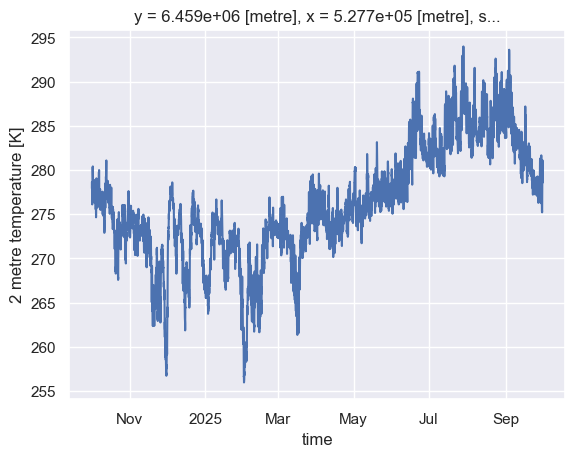

In [9]:
ds['temp'].plot()

## Check for missing dates and fill if missing 
Check there are no datetime gaps in the dataset, because Snow-17 is very strict and I've already had a problem with missing dates on 2023-10-29-00 <--- hour missing

In [10]:
def report_missing_hours(ds, time_var="time"):
    """
    Check for missing hourly timestamps in an xarray dataset.
    """
    time = pd.to_datetime(ds[time_var].values)

    # Expected hourly range
    full_range = pd.date_range(
        start=time.min(),
        end=time.max(),
        freq="1h"
    )

    missing = full_range.difference(time)

    if len(missing) == 0:
        print("No missing hourly timestamps.")
    else:
        print(f"Missing {len(missing)} hourly timestamps:")
        for t in missing:
            print(t)

    return missing

In [11]:
missing_times = report_missing_hours(ds)

No missing hourly timestamps.


And, create the CSV

## Create Forcing File

This version fills the missing data with interpolation, 

In [13]:
# --- 1. Convert temperature to Celsius ---
ds["tavg_degc"] = ds.temp - 273.15

# keep two decimals
ds["tavg_degc"] = ds.tavg_degc.round(2)

# --- 2. Precip rate already in mm/s ---
ds["prec_mm_s-1"] = ds.precip_rate # it must really be in mm per sec because otherwise everything breaks 
# ds["prec_mm_s-1"] = ds.precip_rate * 3600 # even though the forcing file says per second, I really think this must be precip accum over the timestep (1hr = 3600sec)

# --- 3. Convert to dataframe ---
df = ds[["prec_mm_s-1", "tavg_degc"]].to_dataframe().reset_index()

# --- 4. Build continuous hourly time index ---
df = df.set_index("time").sort_index()

full_time = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="1h"
)

df = df.reindex(full_time)

# --- 5. Fill missing values ---
# Precip: assume zero if missing
df["prec_mm_s-1"] = df["prec_mm_s-1"].fillna(0.0)

# Temperature: interpolate
df["tavg_degc"] = df["tavg_degc"].interpolate(method="time")

# --- 6. Restore time column ---
df = df.reset_index().rename(columns={"index": "time"})

# --- 7. Extract time components ---
df["year"] = df["time"].dt.year
df["mo"] = df["time"].dt.month
df["dy"] = df["time"].dt.day
df["hr"] = df["time"].dt.hour

# --- 8. Reorder columns ---
df_out = df[[
    "year",
    "mo",
    "dy",
    "hr",
    "prec_mm_s-1",
    "tavg_degc"
]]

# --- 9. Write to CSV ---
output_file = "/home/cassie/python/models/run_snow17/sites/ppsa2/input/forcing/forcing.snow17bmi.hrrrak_ppsa2_WY2025.csv"

df_out.to_csv(
    output_file,
    index=False,
    float_format="%.6e"
)

print(f"Forcing file written to: {output_file}")

Forcing file written to: /home/cassie/python/models/run_snow17/sites/ppsa2/input/forcing/forcing.snow17bmi.hrrrak_ppsa2_WY2025.csv


In [14]:
df_out

,year,mo,dy,hr,prec_mm_s-1,tavg_degc
0,2024,10,1,5,0.00026,4.77
1,2024,10,1,6,0.00014,5.07
2,2024,10,1,7,0.00006,5.50
3,2024,10,1,8,0.00000,4.96
4,2024,10,1,9,0.00009,4.86
...,...,...,...,...,...,...
8755,2025,10,1,0,0.00000,7.83
8756,2025,10,1,1,0.00000,7.25
8757,2025,10,1,2,0.00000,6.22
8758,2025,10,1,3,0.00000,5.63


In [15]:
# Check the final dataframe for any missing data 
df_out_rename = df_out.rename(columns={'mo':'month', 'dy':'day', 'hr':'hour'})
time = pd.to_datetime(df_out_rename[["year","month","day","hour"]]) 
dt = time.diff().dropna()

if not (dt == pd.Timedelta("1h")).all():
    raise ValueError("Forcing file still has time gaps.")
else:
    print("Forcing file has continuous hourly timestamps.")

Forcing file has continuous hourly timestamps.


## Create Params File

In [16]:
def write_snow17_params(
    output_file,
    hru_id,
    lat,
    lon,
    elev,
    area=1.0
):
    """
    Write a single-HRU Snow-17 parameter file (.txt).

    Parameters
    ----------
    hru_id : HRU identifier
    lat : latitude (deg)
    lon : longitude (deg) [not written to file, for metadata]
    elev : elevation (m)
    area : HRU area (km2), arbitrary for point runs
    """

    # Ensure .txt extension
    if not output_file.endswith(".txt"):
        output_file += ".txt"

    # Parameter values (typical default Snow-17 settings)
    params = [
        f"hru_id {hru_id}",
        f"hru_area {area}",
        f"latitude {lat}",
        f"elev {elev}",
        "scf 1.8",
        "mfmax 2.0",
        "mfmin 0.1",
        "uadj 0.05",
        "si 1500.0",
        "pxtemp 0.0",
        "nmf 0.15",
        "tipm 0.1",
        "mbase 0.0",
        "plwhc 0.03",
        "daygm 0.2",
        "adc1 0.05",
        "adc2 0.09",
        "adc3 0.16",
        "adc4 0.31",
        "adc5 0.54",
        "adc6 0.74",
        "adc7 0.84",
        "adc8 0.89",
        "adc9 0.93",
        "adc10 0.97",
        "adc11 1.00",
    ]

    with open(output_file, "w", encoding="ascii") as f:
        f.write("\n".join(params) + "\n")

    print(f"Snow-17 parameter file written to: {output_file}")

then use it, 

In [17]:
write_snow17_params(
    output_file="/home/cassie/python/models/run_snow17/sites/ppsa2/input/params/snow17_params.hrrrak_ppsa2_WY2025.txt",
    hru_id="hrrrak_ppsa2_WY2025",
    lat=58.262,
    lon=-134.517,
    elev=670
)

Snow-17 parameter file written to: /home/cassie/python/models/run_snow17/sites/ppsa2/input/params/snow17_params.hrrrak_ppsa2_WY2025.txt


## Params File Info

### HRU descriptors 
| Parameter  | Meaning             | Units              |
| ---------- | ------------------- | ------------------ |
| `hru_id`   | HRU name/identifier | text               |
| `hru_area` | Area of HRU         | km² or model units |
| `latitude` | Latitude of HRU     | degrees            |
| `elev`     | Mean elevation      | m                  |


### Snowfall and melt parameters 
| Parameter | Meaning                                   | Typical range   |
| --------- | ----------------------------------------- | --------------- |
| `scf`     | Snow correction factor (gauge undercatch) | 0.8–2.5         |
| `mfmax`   | Max melt factor (non-rain)                | 0.5–5 mm/°C/day |
| `mfmin`   | Min melt factor                           | 0–1 mm/°C/day   |
| `uadj`    | Wind function during rain-on-snow         | 0–0.5           |
| `si`      | Snow water equivalent at 100% cover       | mm              |
| `pxtemp`  | Rain–snow threshold temperature           | °C              |


### Snowpack energy and mass parameters 
| Parameter | Meaning                             | Typical range |
| --------- | ----------------------------------- | ------------- |
| `nmf`     | Negative melt factor                | ~0.1–0.3      |
| `tipm`    | Antecedent temperature index weight | 0–1           |
| `mbase`   | Base melt temperature               | °C            |
| `plwhc`   | Liquid water holding capacity       | 0.01–0.1      |
| `daygm`   | Daily ground melt                   | 0–0.5 mm/day  |


### Areal depletion curve (ADC)
These describe fractional snow cover vs SWE
| Parameter      | Meaning                                      |
| -------------- | -------------------------------------------- |
| `adc1`–`adc11` | Snow cover fraction at increasing SWE levels |


## Create final file, the namelist file for configuration

In [ ]:
def write_snow17_namelist(
    output_file,
    main_id,
    start_time,
    end_time,
    forcing_root="../input/forcing/forcing.snow17bmi.",
    output_root="../output/output.snow17bmi.",
    param_file="../input/params/snow17_params.",
    n_hrus=1,
    model_timestep=3600,
    output_hrus=0,
    warm_start_run=0,
    write_states=1
):
    """
    Write Snow-17 namelist file.

    Parameters
    ----------
    output_file : str
        Full path to output namelist file.
    main_id : str
        Station or basin identifier (e.g., "met_ppsa2_WY2025").
    start_time : str or pandas.Timestamp
        Start time (must convert to YYYYMMDDHH).
    end_time : str or pandas.Timestamp
        End time (must convert to YYYYMMDDHH).
    """

    import pandas as pd

    # Convert times to required format
    start_str = pd.to_datetime(start_time).strftime("%Y%m%d%H")
    end_str = pd.to_datetime(end_time).strftime("%Y%m%d%H")

    # Build parameter file path
    param_path = f"{param_file}{main_id}.txt"

    lines = [
        "&SNOW17_CONTROL",
        "! === run control file for snow17bmi v. 1.x ===",
        "",
        "! -- basin config and path information",
        f'main_id             = "{main_id}"',
        f"n_hrus              = {n_hrus}",
        f'forcing_root        = "{forcing_root}"',
        f'output_root         = "{output_root}"',
        f'snow17_param_file   = "{param_path}"',
        f"output_hrus         = {output_hrus}",
        "",
        "! -- run period information",
        f"start_datehr        = {start_str}",
        f"end_datehr          = {end_str}",
        f"model_timestep      = {model_timestep}",
        "",
        "! -- state start/write flags and files",
        f"warm_start_run      = {warm_start_run}",
        f"write_states        = {write_states}",
        "",
        "! -- filenames only needed if warm_start_run = 1",
        'snow_state_in_root  = "../state/snow17_states."',
        "",
        "! -- filenames only needed if write_states = 1",
        'snow_state_out_root = "../state/snow17_states."',
        "/"
    ]

    with open(output_file, "w", encoding="ascii") as f:
        f.write("\n".join(lines) + "\n")

    print(f"Snow-17 namelist written to: {output_file}")


And, run it to create the file, 

In [ ]:
write_snow17_namelist(
    output_file="/home/cassie/python/models/run_snow17/sites/ppsa2/run/namelist.bmi.hrrrak_ppsa2_WY2025",
    main_id="hrrrak_ppsa2_WY2025",
    start_time="2024-10-01T05:00",
    end_time="2025-07-01T00:00"
)